In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### 生成不同cee的npy

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

def run_parameter_sweep(config):
    """
    运行参数扫描
    config: 字典，包含所有参数
    """
    # 解包配置
    n_runs = config['n_runs']
    c2tsc = config['c2tsc']              # 定值
    scale2 = config['scale2']            # 定值
    param_name = config['param_name']    # 要扫描的参数名
    param_list = config['param_list']    # 要扫描的参数值列表
    data_dir = config['data_dir']        # 保存目录
    
    # 创建保存目录
    os.makedirs(data_dir, exist_ok=True)
    
    # 统计已完成文件（跳过已存在的）
    existing_files = set()
    for f in os.listdir(data_dir):
        if f.endswith(".npy"):
            existing_files.add(f)
    
    total_tasks = len(param_list) * n_runs
    completed = len([f for f in existing_files if param_name in f])
    print(f"总任务数: {total_tasks}, 已完成: {completed}, 待运行: {total_tasks - completed}")
    
    for param_val in param_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_{param_name}_{param_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(data_dir, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = scale2
            params[param_name] = param_val
            
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                param_name: param_val,
                "seed": seed
            })
            print(f"Saved: {param_name}={param_val:.4f}, seed={seed}")

# ========== 使用示例 ==========

# 示例1：扫描 mue_ext_mean
config_mue = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0013,
    'param_name': 'mue_ext_mean',
    'param_list': np.linspace(2.3, 3.1, 15),
    'data_dir': "data/raw_data_explore_mueextmean",
}

# 示例2：扫描 tau_ou
config_tauou = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0013,
    'param_name': 'tau_ou',
    'param_list': np.linspace(5, 12, 30),
    'data_dir': "data/raw_data_explore_tauou",
}

# 示例3：扫描 tau_se
config_tause = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0013,
    'param_name': 'tau_se',
    'param_list': np.linspace(1, 8, 15),
    'data_dir': "data/raw_data_explore_tause",
}

config_cee = {
    'n_runs': 20,
    'c2tsc': 0.8,
    'scale2': 0.0013,
    'param_name': 'cee',
    'param_list': np.concatenate([np.linspace(0.2, 1, 15), np.linspace(1, 1.9, 15)]),
    'data_dir': "data/raw_data_explore_cee",
}

# 运行（取消注释需要的）
run_parameter_sweep(config_cee)

总任务数: 600, 已完成: 300, 待运行: 300
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_1.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_2.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_3.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_4.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_5.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_6.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_7.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_8.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_9.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_10.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_11.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_12.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_13.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_14.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_15.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_16.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_17.npy
跳过: c2tsc_0.8000_scale2_0.0013_cee_0.2000_seed_18.npy
跳过: c2t

d:\mynew\demo_all\models\spindle_3\timeIntegration.py:467: RuntimeWarning: overflow encountered in double_scalars
  seev_rhs = ((1 - seem)**2 * z2ee + (z2ee - 2*tau_se*(z1ee+1))*seev)/tau_se**2
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:467: RuntimeWarning: invalid value encountered in double_scalars
  seev_rhs = ((1 - seem)**2 * z2ee + (z2ee - 2*tau_se*(z1ee+1))*seev)/tau_se**2
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:458: RuntimeWarning: overflow encountered in double_scalars
  seem_rhs = ((1 - seem) * z1ee - seem)/tau_se
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:488: RuntimeWarning: invalid value encountered in add
  k2 = rhs(i, y + 0.5*scale*k1)


Saved: cee=1.6429, seed=2
Saved: cee=1.6429, seed=3
Saved: cee=1.6429, seed=4
Saved: cee=1.6429, seed=5
Saved: cee=1.6429, seed=6
Saved: cee=1.6429, seed=7
Saved: cee=1.6429, seed=8
Saved: cee=1.6429, seed=9
Saved: cee=1.6429, seed=10
Saved: cee=1.6429, seed=11
Saved: cee=1.6429, seed=12
Saved: cee=1.6429, seed=13
Saved: cee=1.6429, seed=14
Saved: cee=1.6429, seed=15
Saved: cee=1.6429, seed=16
Saved: cee=1.6429, seed=17
Saved: cee=1.6429, seed=18
Saved: cee=1.6429, seed=19
Saved: cee=1.6429, seed=20
Saved: cee=1.7071, seed=1


d:\mynew\demo_all\models\spindle_3\timeIntegration.py:423: RuntimeWarning: overflow encountered in double_scalars
  + sigmae_ext**2 ), 0.0
d:\mynew\demo_all\models\spindle_3\timeIntegration.py:491: RuntimeWarning: invalid value encountered in add
  y_next = y + scale*(k1 + 2*k2 + 2*k3 + k4)/6.0


Saved: cee=1.7071, seed=2
Saved: cee=1.7071, seed=3
Saved: cee=1.7071, seed=4
Saved: cee=1.7071, seed=5
Saved: cee=1.7071, seed=6
Saved: cee=1.7071, seed=7
Saved: cee=1.7071, seed=8
Saved: cee=1.7071, seed=9
Saved: cee=1.7071, seed=10
Saved: cee=1.7071, seed=11
Saved: cee=1.7071, seed=12
Saved: cee=1.7071, seed=13
Saved: cee=1.7071, seed=14
Saved: cee=1.7071, seed=15
Saved: cee=1.7071, seed=16
Saved: cee=1.7071, seed=17
Saved: cee=1.7071, seed=18
Saved: cee=1.7071, seed=19
Saved: cee=1.7071, seed=20
Saved: cee=1.7714, seed=1
Saved: cee=1.7714, seed=2
Saved: cee=1.7714, seed=3
Saved: cee=1.7714, seed=4
Saved: cee=1.7714, seed=5
Saved: cee=1.7714, seed=6
Saved: cee=1.7714, seed=7
Saved: cee=1.7714, seed=8
Saved: cee=1.7714, seed=9
Saved: cee=1.7714, seed=10
Saved: cee=1.7714, seed=11
Saved: cee=1.7714, seed=12
Saved: cee=1.7714, seed=13
Saved: cee=1.7714, seed=14
Saved: cee=1.7714, seed=15
Saved: cee=1.7714, seed=16
Saved: cee=1.7714, seed=17
Saved: cee=1.7714, seed=18
Saved: cee=1.7714,

### spindles for param anlysis (spindles_param_explore_valid_limited.csv)
- param = cee
- c2tsc = 0.8; scale2 = 0.0013
- param -> fast/slow spindles

In [3]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这两行 ==========
DATA_FOLDER = "cee"      # 数据文件夹名（会自动找 raw_data_explore_xxx）
PARAM_NAME = "cee"     # 参数名
PARAM_RANGE = (0.2, 2.0)        # 参数范围 (min, max)
# =================================

# 自动生成路径和配置
RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_PREFIX = f"spindles_{DATA_FOLDER}"

def get_phase_and_envelope(signal, filter_args, pad=None):
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    return phase.data.values, filtered, envelope

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked):
    results = []
    if sp is None:
        return results
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        phase_start = slow_phase_masked[start_idx]
        phase_peak = slow_phase_masked[peak_idx]
        phase_end = slow_phase_masked[end_idx]
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": phase_start,
            "phase_at_peak": phase_peak,
            "phase_at_end": phase_end,
            "envelope_at_start": envelope[start_idx],
            "envelope_at_peak": envelope[peak_idx],
            "envelope_at_end": envelope[end_idx],
            "masked": np.isnan(phase_peak),
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}
amplitude_threshold = 2

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM_NAME} 范围: {PARAM_RANGE}")
print(f"输出前缀: {OUTPUT_PREFIX}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 固定解析格式: c2tsc_{val}_scale2_{val}_{param}_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    param_val = float(parts[5])
    seed = int(parts[7])
    
    # 过滤参数范围
    if not (PARAM_RANGE[0] <= param_val <= PARAM_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM_NAME}={param_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    params = {PARAM_NAME: param_val, "c2tsc": c2tsc, "scale2": scale2, "seed": seed}
    
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked))
    
    print(f"  完成")

os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_limited.csv", index=False)

result_df_valid = result_df[~result_df['masked']].copy()
result_df_valid.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_valid_limited.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"相位有效: {len(result_df_valid)} 个")

找到 580 个文件
限定 cee 范围: (0.2, 2.0)
输出前缀: spindles_cee
Processing: cee=0.2000, seed=1
Setting up low-pass filter at 3 Hz


d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成
Processing: cee=0.2000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

  完成
Processing: cee=1.9000, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成
Processing: cee=1.9000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成

总共检测到 7634 个纺锤波
相位有效: 6182 个


### 为cee 画图

加载文件: spindles_cee_explore_valid_limited.csv
分析参数: cee
cee 值: [0.2, 0.2571, 0.3143, 0.3714, 0.4286, 0.4857, 0.5429, 0.6, 0.6571, 0.7143, 0.7714, 0.8286, 0.8857, 0.9429, 1.0, 1.0643, 1.1286, 1.1929, 1.2571, 1.3214, 1.3857, 1.45, 1.5143, 1.5786, 1.6429, 1.7071, 1.7714, 1.8357, 1.9]


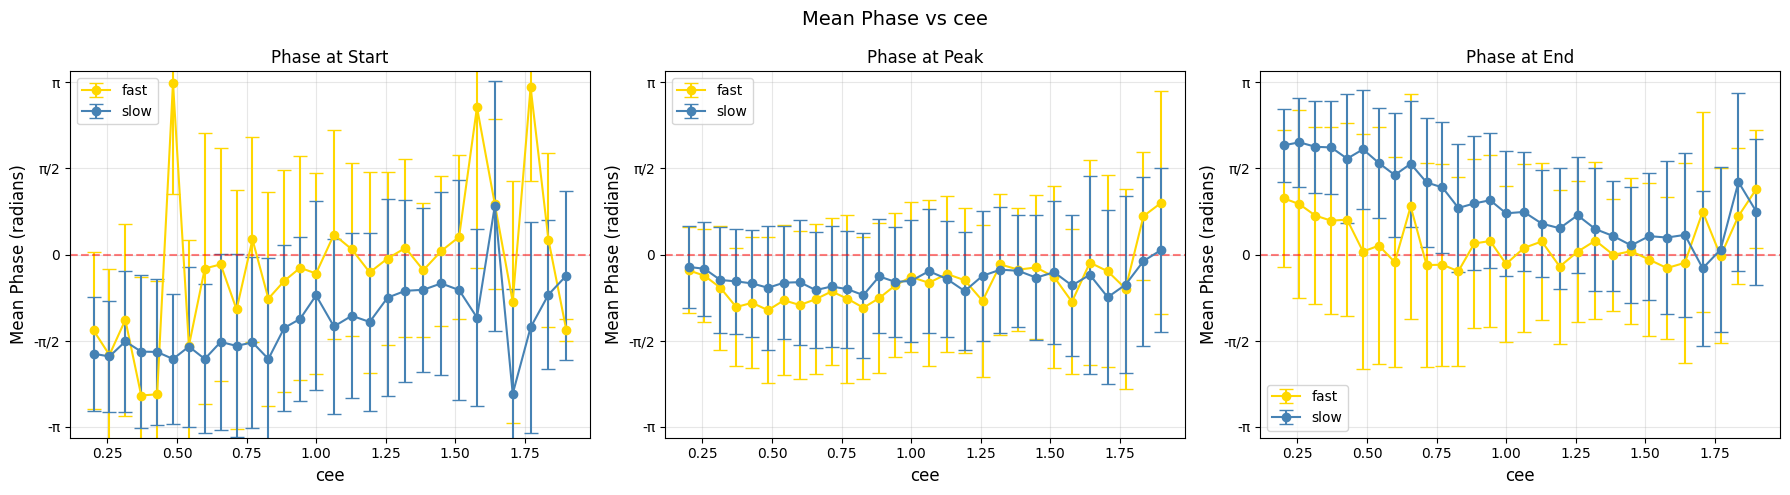

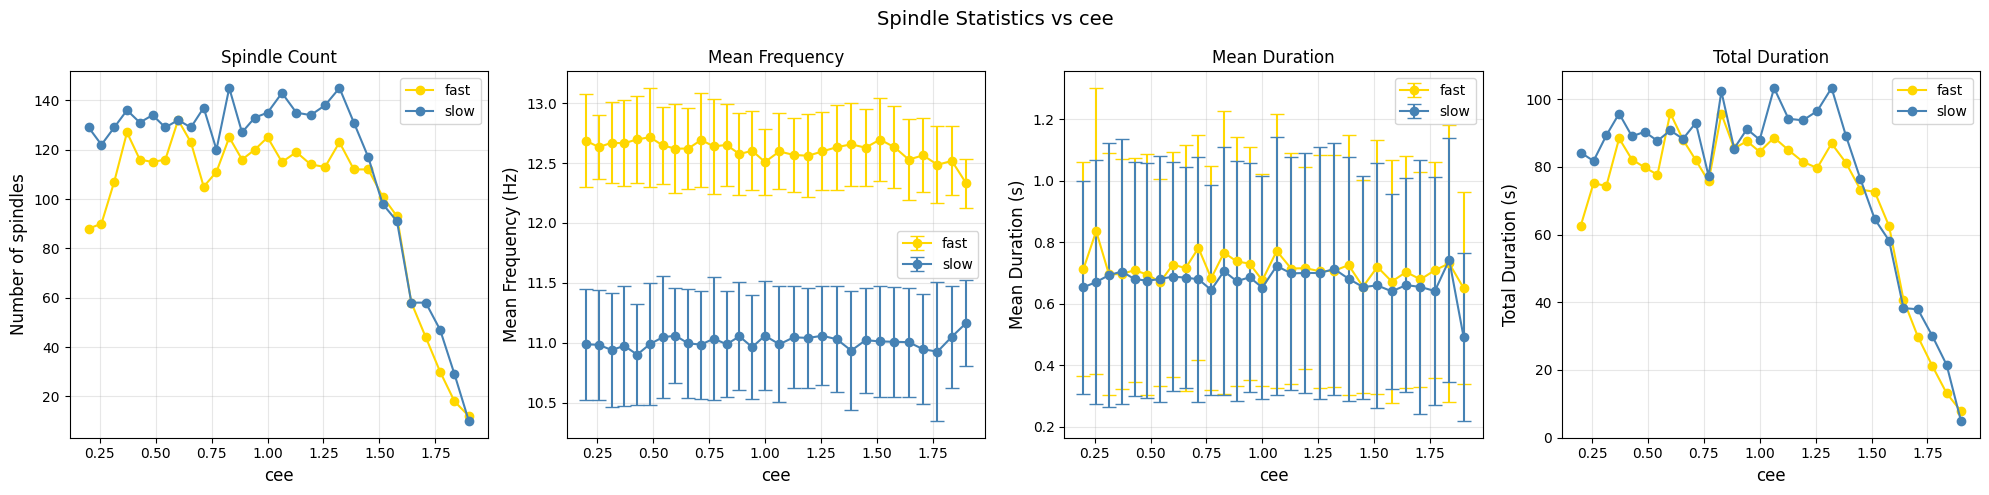


统计摘要

FAST 纺锤波:
  总数量: 2880
  cee=0.20: n= 88, mean_freq=12.69±0.39Hz, mean_dur=0.7121s, total_dur=62.6642s, mean_phase=-0.288 rad
  cee=0.26: n= 90, mean_freq=12.63±0.27Hz, mean_dur=0.8355s, total_dur=75.1973s, mean_phase=-0.386 rad
  cee=0.31: n=107, mean_freq=12.67±0.34Hz, mean_dur=0.6948s, total_dur=74.3392s, mean_phase=-0.605 rad
  cee=0.37: n=127, mean_freq=12.67±0.36Hz, mean_dur=0.6963s, total_dur=88.4250s, mean_phase=-0.958 rad
  cee=0.43: n=116, mean_freq=12.70±0.36Hz, mean_dur=0.7084s, total_dur=82.1724s, mean_phase=-0.881 rad
  cee=0.49: n=115, mean_freq=12.72±0.41Hz, mean_dur=0.6944s, total_dur=79.8592s, mean_phase=-1.015 rad
  cee=0.54: n=116, mean_freq=12.65±0.32Hz, mean_dur=0.6697s, total_dur=77.6798s, mean_phase=-0.835 rad
  cee=0.60: n=132, mean_freq=12.62±0.37Hz, mean_dur=0.7266s, total_dur=95.9053s, mean_phase=-0.921 rad
  cee=0.66: n=123, mean_freq=12.62±0.34Hz, mean_dur=0.7155s, total_dur=88.0028s, mean_phase=-0.816 rad
  cee=0.71: n=105, mean_freq=12.69±0.39Hz, m

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "cee"   # 可选: "mue_ext_mean", "tau_ou", "tau_se", "c_gl"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mue_ext_mean": {
        "file": "spindles_mue_ext_mean_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean",
        "save_prefix": "mue_ext_mean",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
    },
}

# 获取当前配置
config = PARAM_CONFIG.get(PARAM_TYPE, PARAM_CONFIG[PARAM_TYPE])
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")

# ========== 以下代码完全不用改 ==========
df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# 图1：平均相位
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# 图2：四张汇总图
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    counts = subset.groupby(PARAM_NAME).size()
    ax.plot(counts.index, counts.values, 'o-', color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Number of spindles', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_freq = subset.groupby(PARAM_NAME)['frequency'].mean()
    std_freq = subset.groupby(PARAM_NAME)['frequency'].std()
    ax.errorbar(mean_freq.index, mean_freq.values, yerr=std_freq.values,
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_duration = subset.groupby(PARAM_NAME)['duration'].mean()
    std_duration = subset.groupby(PARAM_NAME)['duration'].std()
    ax.errorbar(mean_duration.index, mean_duration.values, yerr=std_duration.values,
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    total_duration = subset.groupby(PARAM_NAME)['duration'].sum()
    ax.plot(total_duration.index, total_duration.values, 'o-', color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s)', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# 打印统计摘要
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    print(f"\n{spindle_type.upper()} 纺锤波:")
    print(f"  总数量: {len(subset)}")
    for val in param_values:
        sub = subset[subset[PARAM_NAME] == val]
        if len(sub) > 0:
            n_spindles = len(sub)
            mean_dur = sub['duration'].mean()
            total_dur = sub['duration'].sum()
            mean_freq = sub['frequency'].mean()
            std_freq = sub['frequency'].std()
            phases = sub['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: n={n_spindles:3d}, mean_freq={mean_freq:.2f}±{std_freq:.2f}Hz, mean_dur={mean_dur:.4f}s, total_dur={total_dur:.4f}s, mean_phase={mean_phase:6.3f} rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: n={n_spindles:3d}, mean_freq={mean_freq:.2f}±{std_freq:.2f}Hz, mean_dur={mean_dur:.4f}s, total_dur={total_dur:.4f}s, no valid phase")

加载文件: spindles_cee_explore_valid_limited.csv
分析参数: cee
cee 值: [0.2, 0.2571, 0.3143, 0.3714, 0.4286, 0.4857, 0.5429, 0.6, 0.6571, 0.7143, 0.7714, 0.8286, 0.8857, 0.9429, 1.0, 1.0643, 1.1286, 1.1929, 1.2571, 1.3214, 1.3857, 1.45, 1.5143, 1.5786, 1.6429, 1.7071, 1.7714, 1.8357, 1.9]


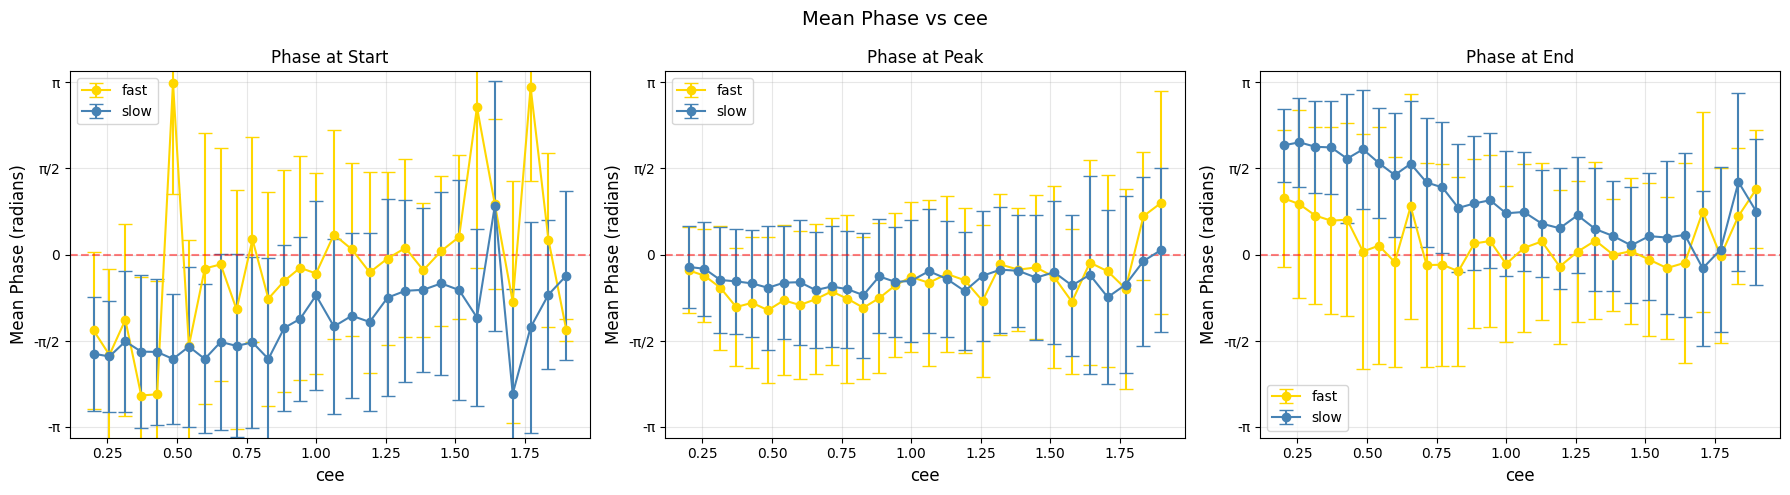


按 seed 统计后的结果示例:
   cee  seed  type  total_duration  count  mean_freq  std_freq  mean_duration  \
0  0.2     1  fast          1.7588      3  12.638708  0.827781       0.586267   
1  0.2     1  slow          3.9220      7  10.808511  0.446160       0.560286   
2  0.2     2  fast          3.0963      4  12.482649  0.601284       0.774075   
3  0.2     2  slow          5.3688      8  11.002817  0.379443       0.671100   
4  0.2     3  fast          4.7707      4  12.769913  0.228078       1.192675   

   std_duration  
0      0.312953  
1      0.341235  
2      0.499002  
3      0.459002  
4      0.534021  

汇总统计示例:
      cee  type  mean_total_duration  std_total_duration  mean_count  \
0  0.2000  fast             3.133210            1.289965        4.40   
1  0.2000  slow             4.210550            1.085271        6.45   
2  0.2571  fast             3.759865            1.560844        4.50   
3  0.2571  slow             4.087665            1.290150        6.10   
4  0.3143  fast   

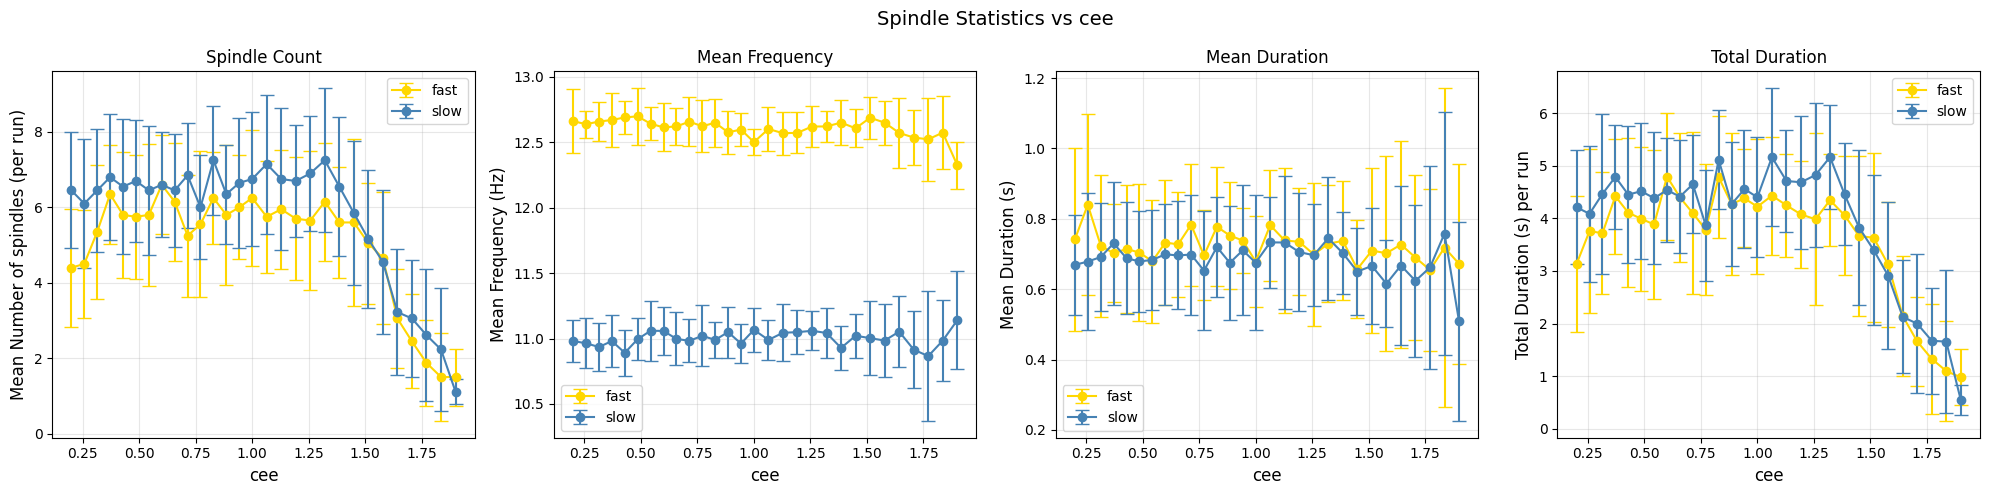


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  cee=0.20: seeds=20, count=4.4±1.6, total_dur=3.13±1.29s, freq=12.66±0.24Hz, dur=0.741±0.261s, phase=-0.288±0.784rad
  cee=0.26: seeds=20, count=4.5±1.4, total_dur=3.76±1.56s, freq=12.64±0.10Hz, dur=0.840±0.257s, phase=-0.386±0.848rad
  cee=0.31: seeds=20, count=5.3±1.8, total_dur=3.72±1.16s, freq=12.66±0.15Hz, dur=0.724±0.202s, phase=-0.605±1.133rad
  cee=0.37: seeds=20, count=6.3±1.3, total_dur=4.42±1.09s, freq=12.67±0.20Hz, dur=0.702±0.139s, phase=-0.958±1.083rad
  cee=0.43: seeds=20, count=5.8±1.7, total_dur=4.11±1.42s, freq=12.69±0.12Hz, dur=0.714±0.181s, phase=-0.881±1.195rad
  cee=0.49: seeds=20, count=5.8±1.7, total_dur=3.99±1.37s, freq=12.70±0.22Hz, dur=0.704±0.195s, phase=-1.015±1.327rad
  cee=0.54: seeds=20, count=5.8±1.9, total_dur=3.88±1.42s, freq=12.64±0.13Hz, dur=0.679±0.175s, phase=-0.835±1.366rad
  cee=0.60: seeds=20, count=6.6±1.3, total_dur=4.80±1.21s, freq=12.61±0.18Hz, dur=0.732±0.177s, phase=-0.921±1.350rad
  cee=0.66: see

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "cee"   # 可选: "mue_ext_mean", "tau_ou", "tau_se", "cee"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mue_ext_mean": {
        "file": "spindles_mue_ext_mean_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean",
        "save_prefix": "mue_ext_mean",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
    },
}

# 获取当前配置
config = PARAM_CONFIG[PARAM_TYPE]
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")

# ========== 以下代码完全不用改 ==========
df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# 图1：平均相位
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 先计算每个 seed 的统计量，再求平均 ==========
# 按参数值和 seed 分组，计算每个 seed 的总时长和纺锤波数量
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
).reset_index()

# 再按参数值和类型分组，计算所有 seed 的均值和标准差
summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),  # 不同 seed 之间平均频率的标准差
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),  # 不同 seed 之间平均时长的标准差
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# 图2：四张汇总图（使用 seed 统计后的数据）
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 子图1：平均纺锤波数量（每个 seed 的数量，再平均）
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率（每个 seed 的平均频率，再平均）
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长（每个 seed 的平均时长，再平均）
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长（每个 seed 的总时长，再平均）
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# 打印统计摘要（修正版）
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            
            # 相位统计（仍用原始数据）
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, no valid phase")